Note: This notebook automatically handles pathing to the 'src' directory. Please ensure that the 'src' and 'configs' folders are in the same parent directory as the notebook's root.

In [1]:
import sys
import os
import datetime
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Environment Setup ---
# Ensure the notebook can access the 'src' directory by moving to the project root
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

# Add the project root to the system path for module importing
sys.path.append(os.getcwd())

print(f"Used seed: 42")

try:
    from src.wizard_logic import load_player_from_config
    import src.wizard_logic as logic
    print(f"✅ Setup successful. Working directory: {os.getcwd()}")
except ImportError as e:
    print(f"❌ Import failed: {e}")

Used seed: 42
✅ Setup successful. Working directory: /mnt/hdd/develop/wizard


In [2]:
# --- 2. Simulation Execution ---
# Objective: Run simulations for 3-6 players and collect win rates
# The function 'run_full_simulation' now handles the loops and resets internally
number_of_games = 1000

print(f"Starting simulation suite ({number_of_games} games per setting)...")
df = logic.run_full_simulation(min_players=3, max_players=6, games_per_round=number_of_games)

# Display the first few rows to verify the results
display(df.head())

Starting simulation suite (1000 games per setting)...


,PlayerCount,Player,Winrate
0,3,Testo_Torsten,25.0
1,3,Gregor_samsa,49.0
2,3,Billy_Bonka,28.1
3,4,Testo_Torsten,12.7
4,4,Gregor_samsa,30.8


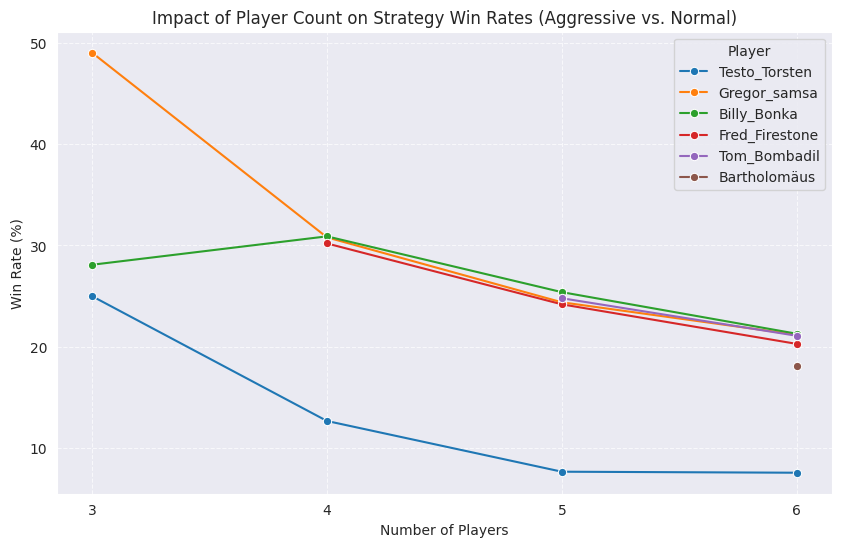

In [3]:
# --- 3. Visualization ---
# Plotting the impact of player count on the win rate of aggressive vs. normal strategies
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="PlayerCount", y="Winrate", hue="Player", marker="o")

plt.title("Impact of Player Count on Strategy Win Rates (Aggressive vs. Normal)")
plt.ylabel("Win Rate (%)")
plt.xlabel("Number of Players")
plt.xticks([3, 4, 5, 6])
plt.grid(True, linestyle='--', alpha=0.7)

os.makedirs("reports", exist_ok=True)
plt.savefig("reports/winrate_analysis.png", dpi=300)

# Highlight the aggressive player (Testo_Torsten) in the plot
plt.show()

In [4]:
# save plot
# --- 4. Metadata ---

# Print Reproducibility Metadata (as requested by the course requirements)
print("-" * 30)
print(f"Simulation Timestamp: {datetime.datetime.now()}")
print(f"Fixed Random Seed: 42")
print(f"Python Version: {sys.version.split()[0]}")
print("-" * 30)

------------------------------
Simulation Timestamp: 2026-01-09 21:10:33.539673
Fixed Random Seed: 42
Python Version: 3.12.3
------------------------------


<Figure size 640x480 with 0 Axes>

## 📊 Interpretation of Results: The Cost of Overestimation

The data shows a significant performance gap between the aggressive strategy and the control group. Based on the implementation, the failure can be traced back to one primary, verifiable cause: **Systematic Bidding Error.**

### 1. The Main Driver: Strategic Overestimation
The core of the "Aggressive" profile is the **Bidding Bias of +0.7**.
* **The Math:** By adding 0.7 to every statistical prediction, the player frequently rounds up to an extra trick that they do not actually "own" based on their cards.
* **The Penalty:** In Wizard, failing a bid is much more punishing than underbidding. Every missed trick results in -10 points. Since the player overestimates their hand in almost every round, the negative points accumulate faster than any bonuses for successful bids can compensate.

### 2. Scalability Issues with Player Count
The graph shows that the failure becomes more extreme as the number of players increases (from 3 to 6):
* In a 3-player game, there is more "room" for error because more cards are distributed to each player, increasing the chance to "luck out" and win a questionable trick.
* In a 6-player game, the card distribution is much tighter. There is less margin for error. A bias of +0.7 in a field of 6 players is statistically "reckless," as the competition for each trick is much higher.

### 3. Conclusion
The primary reason for the aggressive player's failure is not necessarily their playstyle during the tricks, but the **failure to accurately predict their own strength**. The simulation proves that in a game with high penalties like Wizard, an optimistic bias is a losing strategy.